# **Module 3: Regression & Matched Filtering**

date, 2026

## **Problem 1: Likelihood and Parameter Uncertatinty**

You observe a detector that triggers with probability $\theta$ on each trial. You perform $N$ independent trials and observe $k$ triggers. 

---

**(a) Maximum likelihood estimate**

Write the likelihood function 
$$
p(k|\theta)=\binom{N}{k}\theta^k(1-\theta)^{N-k}
$$
Compute the maximum likelihood estimator $\hat{\theta}$.

**(b) Numerical likelihood scan**

For $N=40$ and $k=26$:
1. Plot the log-likelihood $\log p(k|\theta)$ for $0<\theta<1$
2. Mark the maximum

**(c) Uncertainty from likelihood curvature**

Define the $1\sigma$ confidence interval using 
$$
\log L(\theta)=\log L_{\mathrm{max}}-\frac{1}{2}
$$
Numerically determine the upper and lower bounds.

**(d) Interpretation**

Explain in words why the width of the likelihood peak represents uncertainty in the parameter.

## **Problem 2: Why Noise Weighting Matters**

You measure a signal that should follow a linear relation 
$$
y=ax+b
$$
but each data point has a different uncertainty $\sigma_i$. You are given arrays $(x_i,y_i,\sigma_i)$.

---

**(a) Unweighted fit**

Fit the model using ordinary least squares (ignore $\sigma_i$). Plot the data and best-fit line.

**(b) Weighted fit**

Now minimize 
$$
\chi^2=\sum_i \frac{(y_i-ax_i-b)^2}{\sigma_i^2}
$$
Plot the new best-fit line.

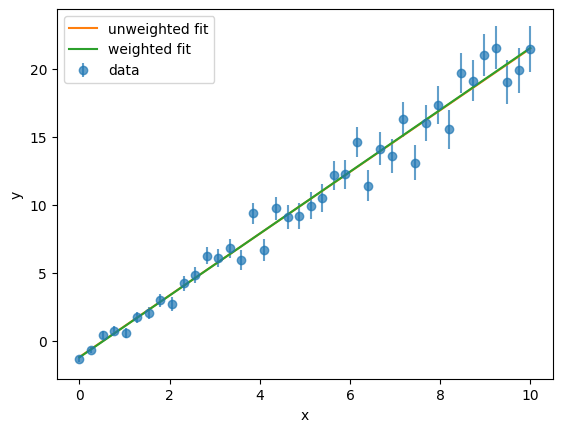

In [8]:
import numpy as np
import matplotlib.pyplot as plt

path = "weighted_regression_dataset.csv"
data = np.loadtxt(path, delimiter=",", skiprows=1)

x = data[:, 0]
y = data[:, 1]
sigma = data[:, 2]

A = np.vstack([x, np.ones_like(x)]).T
a_uwf, b_uwf = np.linalg.lstsq(A, y, rcond=None)[0]

w = 1.0 / sigma**2
Aw = A * np.sqrt(w)[:, None]
yw = y * np.sqrt(w)
a_wls, b_wls = np.linalg.lstsq(Aw, yw, rcond=None)[0]

xx = np.linspace(x.min(), x.max(), 300)

plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt="o", alpha=0.7, label="data")
plt.plot(xx, a_uwf * xx + b_uwf, label="unweighted fit")
plt.plot(xx, a_wls * xx + b_wls, label="weighted fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**(c) Comparison**

1. Which points influenced the weighted fit more strongly?
2. Why does inverse-variance weighting improve parameter estimation?

---

1. Points with smaller $\sigma_i$.
2. It downweights noisy measurements and upweights precise measurements. It is the maximum-likelihood estimator for Gaussian noise.

**(d) Conceptual connection**

Suppose instead of fitting a line, you wanted to estimate the amplitude of a known waveform buried in noise with covariance matrix $\Sigma$.

Explain why you would expect the optimal estimator to weight the data by $\Sigma^{-1}$. (No derivation required.)

---

Similar to the 1D case where the data is weighted by $1/\sigma_i^2$, $\Sigma^{-1}$ whitens the noise and makes uncertainties uncorrelated before fitting. In fact, the Gaussian likelihood is given by 
$$
\exp\left[{(\mathbf{x}-\mathbf{\mu})^T\Sigma^{-1}(\mathbf{x}-\mathbf{\mu})}\right].
$$
This has the effect that directions in data space with large noise variance are suppressed, and directions with small noise dominate.

## **Problem 3: Matched Filtering, Calibration, and Detection Efficiency**

In this assignment you will analyze simulated detector data containing non-white noise, three monoenergetic nuclear decay lines, and a flat background. Your goal is to extract optimal energy estimates, calibrate the detector response, and measure detection efficiency.

You will be provided with two waveform datasets which will be measurements of voltage vs time. The datasets given consist of 'noise' data, and 'events' consisting of trigger pulses. The pulses are embedded in colored (non-white) noise and include:
- Three spectral lines from nuclear decays
- A broad "noise blob" population
- A flat background of random triggers

Your task is to determine the detector performance using three different estimators:
1. Matched/Optimal Filter amplitude estimator (MF)
2. Naive peak estimator (maximum sample or fixed index estimator)
3. Integral estimator (sum/integral over pulse window)

You must compare their energy resolution and detection efficiency.

---

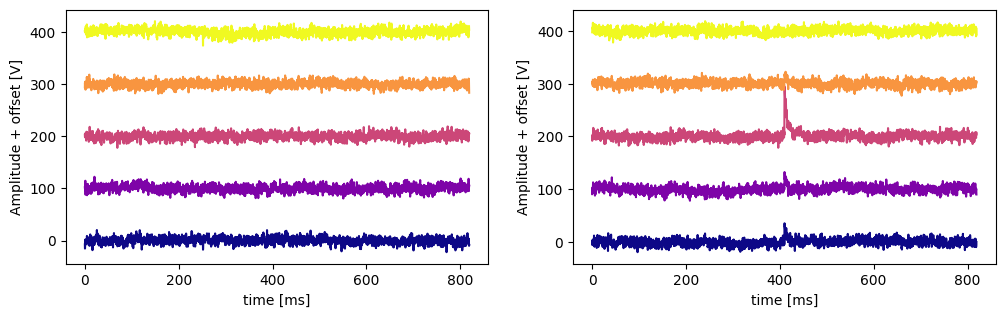

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 5e3
trace_length = 4096
dt = 1/fs

pulse_data = np.load("event_traces.npy")
noise_data = np.load("noise_traces.npy")

#make array of event times
time = np.arange(trace_length)*dt #integer spaced data of lenth of traces, multiplied by time between samples


# use calc_psd() to calculate the PSD of the noise. Note, use the 
# flag 'folded_over=False' if you want the full two sided PSD which 
# is what the optimal filter expects. and use 'folded_over=True' if 
# want the one sided PSD for plotting. Also, the two sided PSD can be 
# folded over with the helper function 'foldpsd'

colors = plt.get_cmap("plasma")
c = colors(np.linspace(0,1,5))


fig, ax = plt.subplots(1,2,figsize=(12,3.3))
for ii in range(5):
    ax[0].plot(time*1e3, noise_data[ii]+ii*100, c=c[ii])# artificially adding a y-offset to seperate the data 
    ax[0].set_xlabel('time [ms]')
    ax[0].set_ylabel('Amplitude + offset [V]')
    ax[1].plot(time*1e3, pulse_data[ii]+ii*100, c=c[ii])# artificially adding a y-offset to seperate the data 
    ax[1].set_xlabel('time [ms]')
    ax[1].set_ylabel('Amplitude + offset [V]')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, fft, ifft, fftfreq, rfftfreq
from scipy.optimize import curve_fit
from scipy.stats import norm

# -------------------------
# Helper functions (provided)
# -------------------------
def foldpsd(psd, fs):
    psd_len = psd.shape[-1]
    psd_folded = np.copy(psd[...,:psd_len//2 + 1])
    psd_folded[..., 1:psd_len//2 + (psd_len)%2] *= 2.0
    f = rfftfreq(psd_len, d=1.0/fs)
    return f, psd_folded


def calc_psd(x, fs=1.0, folded_over=True):
    norm_ = fs * x.shape[-1]
    if folded_over:
        if len(x.shape)==1:
            psd = (np.abs(rfft(x))**2.0)/norm_
        else:
            psd = np.mean(np.abs(rfft(x))**2.0, axis=0)/norm_
        psd[1:x.shape[-1]//2+1 - (x.shape[-1]+1)%2] *= 2.0
        f = rfftfreq(x.shape[-1], d=1.0/fs)
    else:
        if len(x.shape)==1:
            psd = (np.abs(fft(x))**2.0)/norm_
        else:
            psd = np.mean(np.abs(fft(x))**2.0, axis=0)/norm_
        f = fftfreq(x.shape[-1], d=1.0/fs)
    return f, psd


def optimal_filter_amp(signal, template, psd, fs, coupling="AC"):
    signal = np.asarray(signal)
    template = np.asarray(template)
    psd = np.asarray(psd)

    nbins = signal.size
    df = fs / nbins

    psd_safe = psd.astype(float).copy()
    if coupling == "AC":
        psd_safe[0] = np.inf

    tiny = np.finfo(float).tiny
    psd_safe = np.where(np.isfinite(psd_safe), np.maximum(psd_safe, tiny), psd_safe)

    S = fft(template) / nbins / df
    V = fft(signal)   / nbins / df

    phi = np.conjugate(S) / psd_safe
    norm_ = np.real(np.dot(phi, S)) * df
    if norm_ <= 0:
        raise RuntimeError("Computed norm is non-positive (check template/psd)")

    num = np.sum(phi * V) * df
    amp = np.real(num) / norm_
    sigma = 1.0 / np.sqrt(norm_)
    return amp, sigma




def _pick_top_hist_peaks(counts, centers, n):
    """Pick up to n well-separated peak centers from histogram counts."""
    sm = np.convolve(counts, np.ones(3)/3, mode='same')
    order = np.argsort(sm)[::-1]
    chosen = []
    min_sep = (centers[1] - centers[0]) * 6.0
    for idx in order:
        c = centers[idx]
        if all(abs(c - cc) > min_sep for cc in chosen):
            chosen.append(c)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        # fallback: even spacing
        qs = np.linspace(0.1, 0.9, n)
        chosen = list(np.quantile(centers, qs))
    return np.array(sorted(chosen))


def fit_spectrum_curvefit(amplitudes,
                          n_lines=3,
                          mus_guess=None,
                          sig_guess=None,
                          include_flat=True,
                          bins=120,
                          range_vals=None,
                          verbose=False):
    """
    Fit binned counts with n_lines Gaussians + optional flat background using scipy.curve_fit.

    Parameters
    ----------
    amplitudes : 1D array
        Amplitude measurements (one number per event).
    n_lines : int
        Number of Gaussian spectral lines to fit.
    mus_guess : sequence or None
        Optional initial guesses for Gaussian centers (length n_lines). If None, inferred from histogram peaks.
    sig_guess : sequence or None
        Optional initial guesses for standard deviations (length n_lines). If None, default small values based on data span.
    include_flat : bool
        If True, include a flat counts-per-bin background term.
    bins, range_vals : histogram binning passed to np.histogram
    verbose : bool
        Print fitted parameter summary.

    Returns
    -------
    result : dict with keys
        'bin_centers','bin_edges','counts','areas','mus','sigs','weights',
        'flat_counts_per_bin','flat_fraction_est','model_counts','popt','pcov'
    """
    x = np.asarray(amplitudes).ravel()
    N = x.size

    counts, edges = np.histogram(x, bins=bins, range=range_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    span = edges[-1] - edges[0]

    n_gauss = int(n_lines)
    # default guesses
    if mus_guess is None:
        mus_guess = _pick_top_hist_peaks(counts, centers, n_gauss)
    else:
        mus_guess = np.asarray(mus_guess).ravel()
        if mus_guess.size != n_gauss:
            raise ValueError("mus_guess must have length == n_lines")

    if sig_guess is None:
        # narrow for lines: few percent of span
        sig_guess = np.full(n_gauss, max(1e-3, 0.03 * span))
    else:
        sig_guess = np.asarray(sig_guess).ravel()
        if sig_guess.size != n_gauss:
            raise ValueError("sig_guess must have length == n_lines")

    # Model: counts per bin = sum_j area_j * pdf(center | mu_j, sigma_j) * bin_width + flatC
    def _model_counts(x_centers, *p):
        out = np.zeros_like(x_centers, dtype=float)
        ptr = 0
        for g in range(n_gauss):
            area = p[ptr]; mu = p[ptr+1]; sig = p[ptr+2]
            ptr += 3
            out += area * norm.pdf(x_centers, loc=mu, scale=max(1e-9, abs(sig))) * bw
        if include_flat:
            flatC = p[ptr]
            out = out + max(0.0, flatC)
        return out

    # initial parameter vector p0: [area1, mu1, sig1, area2, mu2, sig2, ..., flatC?]
    total_guess_area = N
    base_area = total_guess_area / (n_gauss + (1 if include_flat else 0))
    p0 = []
    for i in range(n_gauss):
        # approximate peak height -> area guess (robust)
        idx_closest = np.argmin(np.abs(centers - mus_guess[i]))
        peak_h = counts[idx_closest]
        est_area = peak_h * (sig_guess[i] * np.sqrt(2*np.pi))
        est_area = max(est_area, base_area * 0.1)
        p0.extend([float(est_area), float(mus_guess[i]), float(sig_guess[i])])

    if include_flat:
        flat_guess = max(0.0, np.median(counts) * 0.2)
        p0.append(float(flat_guess))

    p0 = np.asarray(p0, dtype=float)

    # bounds
    lower = []
    upper = []
    for g in range(n_gauss):
        lower.extend([0.0, edges[0] - 0.2*span, 1e-6])        # area >=0, mu within extended range, sig > 0
        upper.extend([N*10.0, edges[-1] + 0.2*span, span*1.0])
    if include_flat:
        lower.append(0.0)
        upper.append(float(N*0.5))

    try:
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, bounds=(lower, upper), maxfev=50000)
    except Exception as exc:
        if verbose:
            print("curve_fit exception (retrying without bounds):", exc)
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, maxfev=50000)

    # unpack
    ptr = 0
    areas = []
    mus = []
    sigs = []
    for g in range(n_gauss):
        a = float(popt[ptr]); mu = float(popt[ptr+1]); s = abs(float(popt[ptr+2]))
        ptr += 3
        areas.append(a); mus.append(mu); sigs.append(s)

    flatC = float(popt[ptr]) if include_flat else 0.0

    # approximate fractions (area-weighted)
    denom = np.sum(areas) + (flatC * span / bw if include_flat else 0.0)
    if denom <= 0:
        weights = np.array([a / max(1e-12, np.sum(areas)) for a in areas])
        flat_frac = 0.0
    else:
        weights = np.array(areas) / denom
        flat_frac = (flatC * span / bw) / denom if include_flat else 0.0

    model_counts = _model_counts(centers, *popt)

    result = {
        "bin_centers": centers,
        "bin_edges": edges,
        "counts": counts,
        "areas": np.array(areas),
        "mus": np.array(mus),
        "sigs": np.array(sigs),
        "weights": weights,
        "flat_counts_per_bin": float(flatC),
        "flat_fraction_est": float(flat_frac),
        "model_counts": model_counts,
        "popt": popt,
        "pcov": pcov
    }

    if verbose:
        print("mus:", result["mus"])
        print("sigs:", result["sigs"])
        print("areas:", result["areas"])
        print("flat per bin:", result["flat_counts_per_bin"])
        print("flat fraction (est):", result["flat_fraction_est"])

    return result



# -------------------------
# Utilities
# -------------------------

def make_template(time, tau_rise=100e-6, tau_fall=5e-3):
    """
    s(t) ~ exp(-t/t_fall) - exp(-t/t_rise) for t>=0, else 0, normalized to max=1.
    """
    n = time.size
    dt = time[1] - time[0]
    t_rel = (np.arange(n) - n // 2) * dt

    s = np.zeros(n, dtype=float)
    mask = t_rel >= 0
    tpos = t_rel[mask]
    s[mask] = np.exp(-tpos / tau_fall) - np.exp(-tpos / tau_rise)

    m = np.max(s)
    s = s / m

    return s

def mf_amplitudes(pulse_traces, template, psd2, fs):
    """Apply optimal_filter_amp to every event; returns arrays of amps and sigmas."""
    pulse_traces = pulse_traces
    amps = np.zeros(pulse_traces.shape[0])
    sigs = np.zeros(pulse_traces.shape[0])
    for i in range(pulse_traces.shape[0]):
        amps[i], sigs[i] = optimal_filter_amp(pulse_traces[i], template, psd2, fs, coupling="AC")
    return amps, sigs

#### **Part I: Matched Filter Amplitudes**

1. Construct a noise power spectral desity (PSD), $J(f)$, estimate using the noise-only dataset. Plot the (one-sided) PSD on a log-log plot.

2. Build a matched filter using a template pulse $s(t)$ and the measured PSD:
    $$
    a_{\mathrm{MF}}=\frac{\sum_k \tilde{s}^*(f_k)\tilde{d}(f_k)/J(f_k)}{\sum_k |\tilde{s}(f_k)|^2/J(f_k)}
    $$
    where $\tilde{d}(f_k)$ and $\tilde{s}(f_k)$ are the Fourier transforms of the data and template respectively. Our pulse template is normalized to have a maximum amplitude of one, and scales as 
    $$
    s(t)\propto \exp(-t/\tau_{\mathrm{fall}})-\exp(-t/\tau_{\mathrm{rise}})
    $$
    where $\tau_{\mathrm{rise}}=100\,\mathrm{\mu s}$ and $\tau_{\mathrm{fall}}=5\, \mathrm{ms}$.

3. Apply the matched filter to all events and extract an amplitude for each pulse.

4. Plot a histogram of the measured amplitudes.

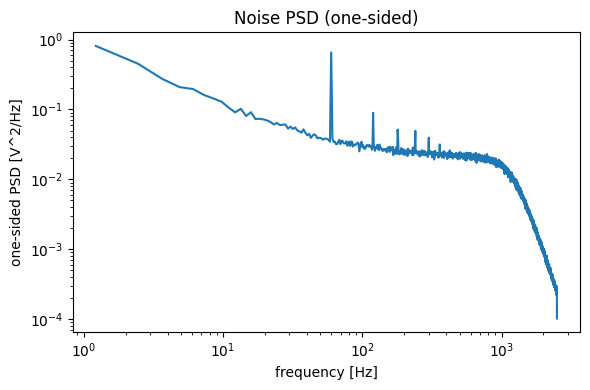

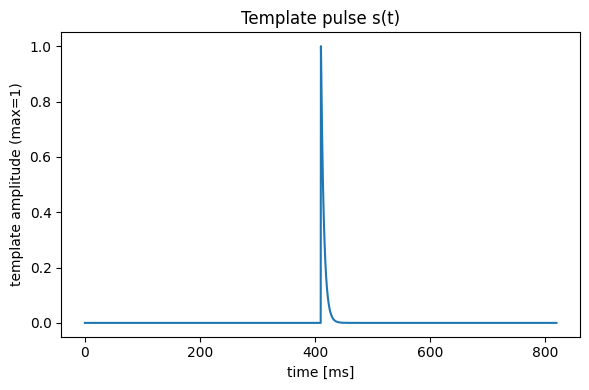

MF amplitude stats:
  mean = 41.74785908295
  std  = 29.532811983671408
  median sigma (predicted) = 2.498543467405175


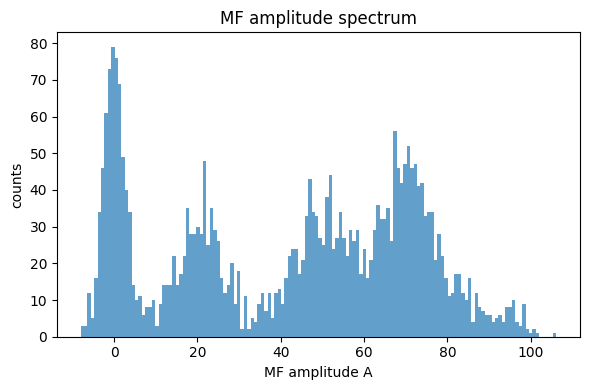

In [18]:
# 1.

# Two-sided PSD for the filter
f2, psd2 = calc_psd(noise_data, fs=fs, folded_over=False)

# One-sided PSD just for plotting
f1, psd1 = foldpsd(psd2, fs)

plt.figure(figsize=(6,4))
mask = f1 > 0
plt.loglog(f1[mask], psd1[mask])
plt.xlabel("frequency [Hz]")
plt.ylabel("one-sided PSD [V^2/Hz]")
plt.title("Noise PSD (one-sided)")
plt.tight_layout()
plt.show()

# 2.

template = make_template(time, tau_rise=100e-6, tau_fall=5e-3)

plt.figure(figsize=(6,4))
plt.plot(time*1e3, template)
plt.xlabel("time [ms]")
plt.ylabel("template amplitude (max=1)")
plt.title("Template pulse s(t)")
plt.tight_layout()
plt.show()

# 3.

amps_mf, sigs_mf = mf_amplitudes(pulse_data, template, psd2, fs)

print("MF amplitude stats:")
print("  mean =", np.mean(amps_mf))
print("  std  =", np.std(amps_mf))
print("  median sigma (predicted) =", np.median(sigs_mf))

# 4.

plt.figure(figsize=(6,4))
plt.hist(amps_mf, bins=140, alpha=0.7)
plt.xlabel("MF amplitude A")
plt.ylabel("counts")
plt.title("MF amplitude spectrum")
plt.tight_layout()
plt.show()

#### **Part II: Spectral Model and Maximum Likelihood Fit**

The amplitude spectrum consistes of three spectral lines, a Gaussian noise population, and a flat background. 

Model the probability density as 
$$
p(A)=\sum_{i=1}^3 \omega_i\mathcal{N}(A|\mu_i,\sigma_i^2)+\omega_{\mathrm{noise}}\mathcal{N}(A|\mu_n,\sigma_n^2)+\omega_{\mathrm{flat}}\frac{1}{A_{\mathrm{max}}-A_{\mathrm{min}}},
$$
with 
$$
\sum_j \omega_j=1.
$$
1. Perform an unbinned maximum likelihood fit to extract all model parameters:
    $$
    \{\omega_i,\mu_i,\sigma_i\}, \omega_{\mathrm{noise}}, \mu_n, \sigma_n, \omega_{\mathrm{flat}}.
    $$

2. Identify the three signal peaks and determine their measured amplitudes $A_1, A_2, A_3$ and uncertainties.

mus: [-5.28390378e-02  2.08540280e+01  5.00256361e+01  7.05942264e+01]
sigs: [2.48566206 4.92858632 6.3645473  6.18308253]
areas: [561.676125   427.46089569 572.9721032  796.29010833]
flat per bin: 5.349642101543671
flat fraction (est): 0.2139602738254285


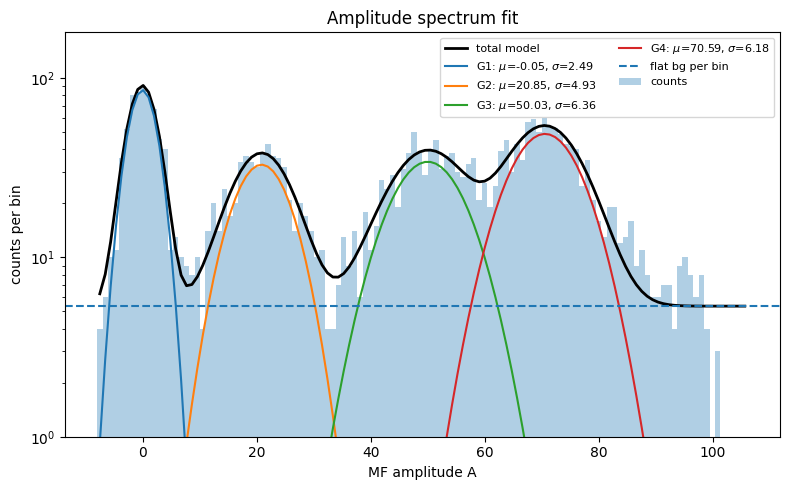

Noise blob: mu, sigma = -0.0528390377555538 2.4856620606446813
Lines:
  line 1: mu=20.854, sigma=4.92859
  line 2: mu=50.0256, sigma=6.36455
  line 3: mu=70.5942, sigma=6.18308


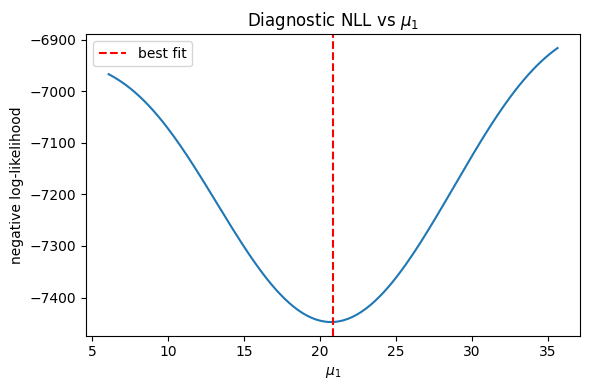

In [7]:
res = fit_spectrum_curvefit(
    amps_mf,
    n_lines=4,
    mus_guess=None,
    sig_guess=None, 
    include_flat=True,
    bins=120,
    range_vals=None,
    verbose=True
)

bw = res["bin_edges"][1] - res["bin_edges"][0]

plt.figure(figsize=(8,5))
plt.bar(res["bin_centers"], res["counts"], width=bw, alpha=0.35, label="counts")
plt.plot(res["bin_centers"], res["model_counts"], "k-", lw=2, label="total model")

for i, area in enumerate(res["areas"]):
    comp = area * norm.pdf(res["bin_centers"], loc=res["mus"][i], scale=res["sigs"][i]) * bw
    plt.plot(res["bin_centers"], comp, lw=1.5, label=fr"G{i+1}: $\mu$={res['mus'][i]:.2f}, $\sigma$={res['sigs'][i]:.2f}")

if res["flat_counts_per_bin"] > 0:
    plt.axhline(res["flat_counts_per_bin"], ls="--", lw=1.5, label="flat bg per bin")

plt.yscale("log")
plt.ylim(1, max(10, np.max(res["counts"])*2))
plt.xlabel("MF amplitude A")
plt.ylabel("counts per bin")
plt.title("Amplitude spectrum fit")
plt.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()


mus = res["mus"]
sigs = res["sigs"]

noise_idx = int(np.argmin(mus))
line_idx = sorted([i for i in range(len(mus)) if i != noise_idx], key=lambda i: mus[i])

mu_noise, sig_noise = mus[noise_idx], sigs[noise_idx]
mu_lines = mus[line_idx]
sig_lines = sigs[line_idx]

print("Noise blob: mu, sigma =", mu_noise, sig_noise)
print("Lines:")
for j,i in enumerate(line_idx, start=1):
    print(f"  line {j}: mu={mus[i]:.6g}, sigma={sigs[i]:.6g}")


# Diagnostic NLL scan for the FIRST SIGNAL LINE (mu = 20.89)

mu0 = mu_lines[0]
sigma0 = sig_lines[0]

popt = res["popt"].copy()

centers = res["bin_centers"]
counts  = res["counts"]
bw = res["bin_edges"][1] - res["bin_edges"][0]

def model_counts(x_centers, p):
    out = np.zeros_like(x_centers, dtype=float)
    ptr = 0
    n_gauss = 4
    
    for g in range(n_gauss):
        area = p[ptr]
        mu   = p[ptr+1]
        sig  = abs(p[ptr+2])
        ptr += 3
        out += area * norm.pdf(x_centers, loc=mu, scale=sig) * bw
    
    flatC = p[ptr]
    out += flatC
    return out

def poisson_nll(p):
    lam = model_counts(centers, p)
    lam = np.clip(lam, 1e-12, None)
    return np.sum(lam - counts * np.log(lam))

mu_indices = [1,4,7,10]
mu_scan_index = min(mu_indices, key=lambda i: abs(popt[i]-mu0))

mu_vals = np.linspace(mu0 - 3*sigma0, mu0 + 3*sigma0, 200)
nll_vals = []

for mu_test in mu_vals:
    ptest = popt.copy()
    ptest[mu_scan_index] = mu_test
    nll_vals.append(poisson_nll(ptest))

plt.figure(figsize=(6,4))
plt.plot(mu_vals, nll_vals)
plt.axvline(mu0, color='r', linestyle='--', label='best fit')
plt.xlabel(r"$\mu_1$")
plt.ylabel("negative log-likelihood")
plt.title(r"Diagnostic NLL vs $\mu_1$")
plt.legend()
plt.tight_layout()
plt.show()

#### **Part III: Energy Calibration**

You will be provided with the true energies of the three lines:
$$
E_1^{\mathrm{true}}=25\,\mathrm{keV}, E_2^{\mathrm{true}}=65\,\mathrm{keV}, E_3^{\mathrm{true}}=100\,\mathrm{keV}.
$$
The detector response follows nonlinear saturation model 
$$
E_{\mathrm{recon}}=a\left(1-\exp\left(-\frac{E_{\mathrm{true}}}{b}\right)\right).
$$
1. Fit for calibration parameters $a$ and $b$.
2. Construct the inverse calibration function to convert measured amplitudes to reconstructed energy $E_{\mathrm{rec}}$.
3. Convert the full amplitude spectrum into an energy spectrum.
4. Comment on the benefits of the above saturation model vs a polynomial/spline fit.

Calibration fit: a = 180.66190404224264  b = 201.49836094829084


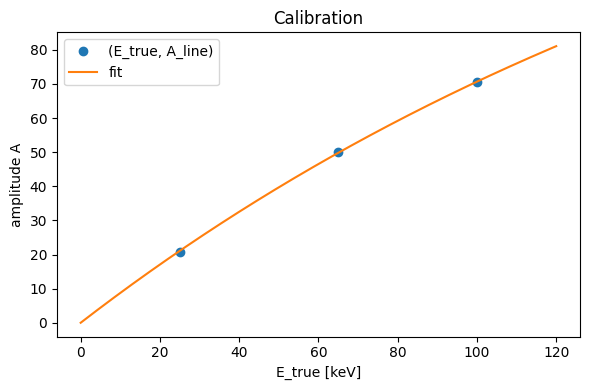

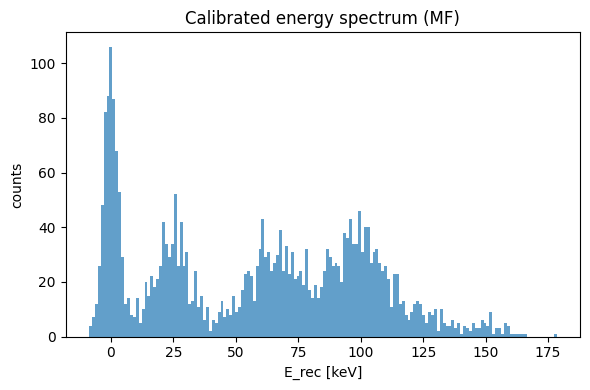

In [8]:
def sat_model(E_true, a, b):
    return a * (1.0 - np.exp(-E_true / b))

def fit_calibration(E_true, A_meas):
    E_true = np.asarray(E_true, float)
    A_meas = np.asarray(A_meas, float)
    a0 = 1.2 * np.max(A_meas)
    b0 = np.mean(E_true)
    popt, pcov = curve_fit(sat_model, E_true, A_meas, p0=(a0,b0))
    return popt, pcov

def inv_calibration(A, a, b):
    return -b * np.log(1.0 - A / a)

E_true = np.array([25.0, 65.0, 100.0])
A_lines = mu_lines.copy()

(a_cal, b_cal), pcov_cal = fit_calibration(E_true, A_lines)
print("Calibration fit: a =", a_cal, " b =", b_cal)

Egrid = np.linspace(0, 120, 400)
plt.figure(figsize=(6,4))
plt.plot(E_true, A_lines, "o", label="(E_true, A_line)")
plt.plot(Egrid, sat_model(Egrid, a_cal, b_cal), "-", label="fit")
plt.xlabel("E_true [keV]")
plt.ylabel("amplitude A")
plt.title("Calibration")
plt.legend()
plt.tight_layout()
plt.show()

E_rec_all = inv_calibration(amps_mf, a_cal, b_cal)

plt.figure(figsize=(6,4))
plt.hist(E_rec_all, bins=160, alpha=0.7)
plt.xlabel("E_rec [keV]")
plt.ylabel("counts")
plt.title("Calibrated energy spectrum (MF)")
plt.tight_layout()
plt.show()

The detectors might saturate at high energy with large signals due to finite measuring range or other physical limitations. This saturation model explicitly has an asymptote. Moreover, this model increases monotonically and concave down, which can be a well-behaved candidate simulating the detector response. On the other hand, the polynomial/spine model does not have the saturation behavior and can introduce non-monotonic regions, which are adundant and unreasonable for our problem. 

#### **Part IV: Detection Threshold**

Define a detection threshold using the noise population:
$$
E_{\mathrm{thresh}}=\mu_n+5\sigma_n.
$$
1. Determine the corresponding energy threshold after calibration.
2. Plot the calibrated spectrum and mark the threshold.

A_thresh = 12.375471265467853
E_thresh [keV] = 14.29829677586646


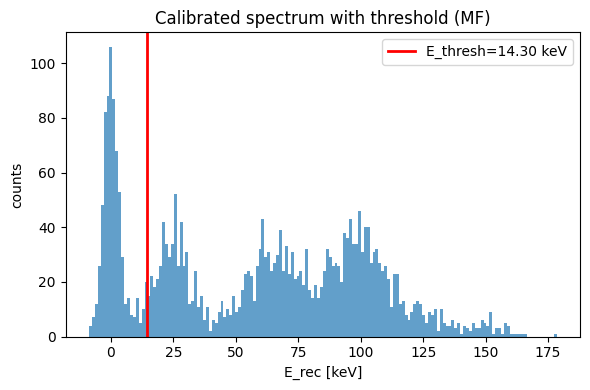

In [9]:
A_thresh = mu_noise + 5.0 * sig_noise
E_thresh = inv_calibration(A_thresh, a_cal, b_cal)

print("A_thresh =", A_thresh)
print("E_thresh [keV] =", E_thresh)

plt.figure(figsize=(6,4))
plt.hist(E_rec_all, bins=160, alpha=0.7)
plt.axvline(E_thresh, lw=2, color="red", label=f"E_thresh={E_thresh:.2f} keV")
plt.xlabel("E_rec [keV]")
plt.ylabel("counts")
plt.title("Calibrated spectrum with threshold (MF)")
plt.legend()
plt.tight_layout()
plt.show()

#### **Part V: Detection Efficience**

You will now simulate pulses of known amplitude.

1. Inject fake pulsees of known true energy into real noise.
2. Process them through the full analysis chain.
3. A pulse is "detected" if $E_{\mathrm{rec}}>E_{\mathrm{thresh}}$.

Measure the efficiency 
$$
\epsilon(E)=\frac{N_{\mathrm{detected}(E)}}{N_{\mathrm{injected}(E)}}.
$$
Plot efficiency vs energy.

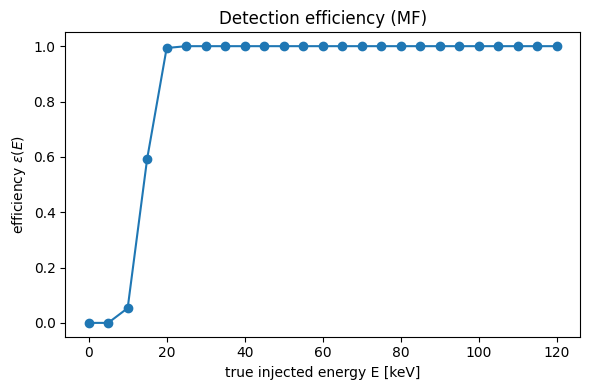

In [11]:
def efficiency_curve(noise_traces, template, psd2, fs, a_cal, b_cal, E_thresh,
                     E_grid, n_inj=300, seed=0):
    rng = np.random.default_rng(seed)
    eff = []
    noise_traces = np.asarray(noise_traces)

    for E in E_grid:
        A_true = sat_model(E, a_cal, b_cal)
        idx = rng.integers(0, noise_traces.shape[0], size=n_inj)
        noise_sel = noise_traces[idx]
        inj = noise_sel + A_true * template[None, :]

        A_rec, _ = mf_amplitudes(inj, template, psd2, fs)
        E_rec = inv_calibration(A_rec, a_cal, b_cal)

        eff.append(np.mean(E_rec > E_thresh))
        
    return np.asarray(eff)

E_scan = np.linspace(0, 120, 25)
eps = efficiency_curve(noise_data, template, psd2, fs, a_cal, b_cal, E_thresh,
                       E_scan, n_inj=300, seed=0)

plt.figure(figsize=(6,4))
plt.plot(E_scan, eps, "o-")
plt.xlabel("true injected energy E [keV]")
plt.ylabel(r"efficiency $\varepsilon(E)$")
plt.title("Detection efficiency (MF)")
plt.tight_layout()
plt.show()

#### **Part VI: Alternative Estimators**

Repeat the entire analysis using:

1. Peak estimator: maximum sample value
2. Integral estimator: summed pulse area

For each estimator:

* Recalibrate the energy scale
* Compute resolution $\sigma_E(E)$ at each spectral line
* Compute detection efficiency curve

#### **Final Comparison**

Provide a comparison table including:

Estimator | Energy Resolution | Threshold Energy
:---: | :---: | :---:
Matched Filter | 5.55 keV | 14.30 keV
Peak | |
Integral | |

and overlay the efficiency curves on a single plot.

**Discussion:** Explain physically why the matched filter performs differently from the other estimators. Discuss how colored noise impacts optimal filtering and detection efficiency.

In [54]:
def dEdA(A, a, b):
    # derivative of E(A) = -b ln(1 - A/a)
    return b / (a - A)

E_lines = inv_calibration(mu_lines, a_cal, b_cal)
sigmaE_lines = dEdA(mu_lines, a_cal, b_cal) * sig_lines

for i in range(3):
    print(f"Line {i+1}:")
    print(f"  mu_A   = {mu_lines[i]:.4f}")
    print(f"  sig_A  = {sig_lines[i]:.4f}")
    print(f"  E_rec  = {E_lines[i]:.2f} keV")
    print(f"  sigmaE = {sigmaE_lines[i]:.2f} keV")

Line 1:
  mu_A   = 20.8892
  sig_A  = 4.4192
  E_rec  = 24.59 keV
  sigmaE = 5.55 keV
Line 2:
  mu_A   = 50.2296
  sig_A  = 6.0892
  E_rec  = 65.47 keV
  sigmaE = 9.45 keV
Line 3:
  mu_A   = 70.4809
  sig_A  = 5.9007
  E_rec  = 99.78 keV
  sigmaE = 10.94 keV
